<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/260918_%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge


*   일본의 대형 온라인 쇼핑몰인 Mercari사의 제품에 대해 가격을 예측하는 과제로, 제공되는 데이터 세트는 제품에 대한 여러 속성 및 제품 설명 등의 텍스트 데이터로 구성됨. Mercari사는 이러한 데이터를 기반으로 예상 가격을 판매자들에게 제공하고자 함. 이와 같은 프로세스를 구현하기 위해 판매자는 제품명, 브랜드명, 카데고리, 제품 설명 등 다양한 속성 정보를 입력하게 되고, ML 모델은 이 속성에 다라 제품의 예측 가격을 판매자에게 자동으로 제공할 수 있음.

### 데이터 전처리



In [2]:
# 필요한 라이브러리와 함께 데이터를 DataFrame으로 로딩하고 데이터를 간략히 살펴봄

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df=pd.read_csv('/content/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1165403, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [3]:
# 피처의 타입과 Null 여부 확인

print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165403 entries, 0 to 1165402
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1165403 non-null  int64  
 1   name               1165403 non-null  object 
 2   item_condition_id  1165403 non-null  int64  
 3   category_name      1160395 non-null  object 
 4   brand_name         667920 non-null   object 
 5   price              1165403 non-null  float64
 6   shipping           1165403 non-null  int64  
 7   item_description   1165400 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 71.1+ MB
None


brand_name 칼럼의 경우 가격에 영향을 미치는 중요 요인으로 판단되나, 매우 많은 Null 값을 가지고 있음. category_name은 5008건의 Null 데이터를 가지고 있음. item_description의 Null 값은 3건으로 미미함. 이 Null 데이터는 이후에 적절한 문자열로 치환할 것임.

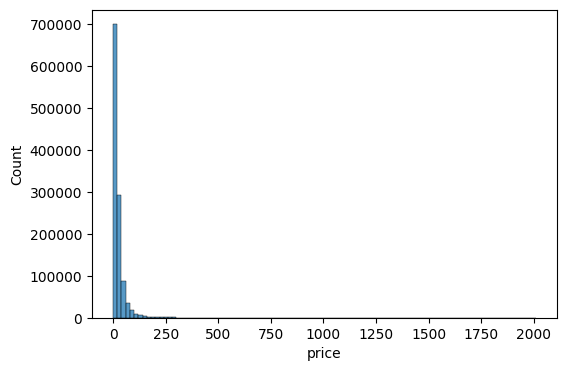

In [4]:
# Target 값인 price 칼럼의 데이터 분포도

import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()



*   회귀에서 정규 분포도가 왜곡되어 있을 경우 보통 로그를 씌워 반환하면 대부분 정규 분포의 형태를 가지게 됨.


price 값이 비교적 적은 가격을 가진 데이터 값에 왜곡되어 분포하고 있으므로 price 칼럼을 로그 값으로 변환한 뒤 분포도를 다시 살펴봄.



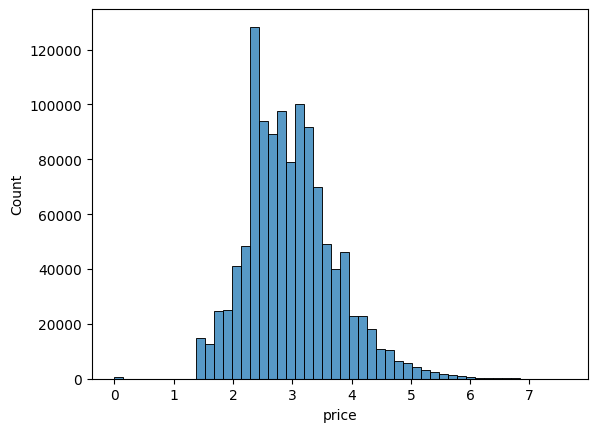

In [5]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

로그 값으로 변환하면 price 값이 비교적 정규 분포에 가까운 데이터를 이루게 됨.

In [6]:
# 데이터 세트의 price 칼럼을 원래 값에서 로그로 변환된 값으로 변경

mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [7]:
# 다른 피처의 값도 살펴보면

print('shipping 값 유형: \n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형: \n', mercari_df['item_condition_id'].value_counts())

shipping 값 유형: 
 shipping
0    644085
1    521318
Name: count, dtype: int64
item_condition_id 값 유형: 
 item_condition_id
1    503256
3    339956
2    295231
4     25075
5      1885
Name: count, dtype: int64


shipping 칼럼은 배송비 유무이며, 값이 비교적 균일함. item_condition_id는 판매자가 제공하는 제품 상태로, 1, 2, 3 값이 주를 이룸.

In [8]:
# item_description 칼럼에서 'No description yet'값이 얼마나 있는지 살펴봄

boolean_cond = mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(64936)

item_description이 'No description yet'로 되어 있는 로우는 64936건임. 'No description yet'의 경우도 Null과 마찬가지로 의미 있는 속성값으로는 사용될 수 없으므로 적절한 값으로 변경해야 함.


category_name은 '/'로 분리된 카테고리를 하나의 문자열로 나타내고 있음. (e.g. 'Men/Tops/T-shirts'는 대분류 'Men', 중분류 'Tops', 소분류 'T-shirts'로 나눌 수 있음. category_name은 텍스트이므로 피처 추출 시 tokenizer를 '/'로 해 단어를 분리해 벡터화할 수도 있으나, 여기서는 category_name의 '/'를 기준으로 단어를 토큰화 해 각각 별도의 피처로 저장하고 이를 이용해 알고리즘을 학습시키고자 함.



*   파이썬은 문자열에 split(tokenizer문자) 함수를 호출하면 tokenizer 문자에 따라 문자열을 분리해 리스트로 반환함.




In [11]:
# '/'를 기준으로 대, 중, 소분류를 효과적으로 분리하기 위해 별도의 함수 생성

def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other_Null', 'Other_Null', 'Other_Null']     ## 만일 category_name이 Null일 경우에는 split() 함수가 Error를 발생시키므로 이 Error를 except catch해 대, 중, 소 분류 모두 'Other Null' 값 부여

## 위의 함수를 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

print('대분류 유형: \n', mercari_df['cat_dae'].value_counts())
print('중분류 개수: ', mercari_df['cat_jung'].nunique())       ## 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('소분류 개수: ', mercari_df['cat_so'].nunique())

대분류 유형: 
 cat_dae
Women                     522171
Beauty                    163564
Kids                      134677
Electronics                96325
Men                        73600
Home                       53618
Vintage & Collectibles     36602
Other                      35689
Handmade                   24267
Sports & Outdoors          19882
Other_Null                  5008
Name: count, dtype: int64
중분류 개수:  114
소분류 개수:  864


대분류의 경우 Women, Beauty, Kids 등의 분류가 매우 많음. 중분류 유형은 114개, 소분류는 864개로 구성되어 있음.

In [12]:
# brand_name, category_name, item_description 칼럼의 Null값은 일괄적으로 'Other Null'로 동일하게 변경

mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other Null')

mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


### 피처 인코딩과 피처 벡터화

Mercari Price Suggestion에 이용되는 데이터 세트는 문자열 칼럼이 많음. 이 문자열 칼럼 중 레이블 또는 원-핫 인코딩을 수행하거나 피처 벡터화로 변환할 컬럼을 선별할 수 있음. 먼저 이 피처를 어떤 방식으로 변환할지 검토한 후에 추후에 일괄적으로 전체 속성의 변환 작업을 적용할 수 있음.

Mercari Price Suggestion에서 예측 모델은 price 값, 즉 상품 가격을 예측해야 하므로 회귀 모델을 기반으로 함. 선형 회귀 모델과 회귀 트리 모델을 모두 적용하며, 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩을 적용함. 피처 벡터화의 경우는 비교적 짧은 텍스트의 경우는 Count 기반의 벡터화를, 긴 텍스트는 TF-IDF 기반의 벡터화를 적용함.

In [13]:
# brand_name 칼럼

print('brand_name의 유형 건수: ', mercari_df['brand_name'].nunique())
print('brand_name sample 5건: \n', mercari_df['brand_name'].value_counts()[:5])

brand_name의 유형 건수:  4514
brand_name sample 5건: 
 brand_name
Other Null           497483
Nike                  42531
PINK                  42488
Victoria's Secret     37944
LuLaRoe               24261
Name: count, dtype: int64


brand_name의 경우 대부분 명료한 문자열로 되어 있음. 별도의 피처 벡터화 형태로 만들 필요 없이 인코딩 변환을 적용하면 됨.

In [14]:
# name 칼럼

print('name의 종류 개수: ', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수:  978473
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


상품명의 경우 종류가 매우 많음. 전체 데이터가 978473건이므로 개별적으로 거의 고유한 상품명을 가지고 있음을 알 수 있음. Name 속성은 유형이 매우 많고, 적은 단어 위주의 텍스트 형태로 되어 있으므로 Count 기반으로 피처 벡터화 변환을 적용함.

category_name 칼럼은 이전에 전처리를 통해 해당 칼럼은 대, 중, 소 분류 세 개의 칼럼인 cat_dae, cat_jung, cat_so 칼럼으로 분리되었음. cat_dae, cat_jung, cat_so 칼럼도 원-핫 인코딩을 적용함.

shipping 칼럼은 배송비 무료 여부로서 0과 1, 두 가지 유형의 값을 가지고 있으며, item_condition_id는 상품 상태로서 1, 2, 3, 4, 5의 다섯 가지 유형의 값을 가짐. 이 두 칼럼 모두 원-핫 인코딩을 적용함.

In [15]:
# item_description 칼럼

pd.set_option('max_colwidth', 200)    ## 데이터 세트에서 가장 긴 텍스트를 가지고 있으므로
print('item_description 평균 문자열 크기: ', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기:  145.70572068203018


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


평균 문자열이 145자로 비교적 크기 때문에 해당 칼럼은 TF-IDF로 변환함.

In [16]:
# 주요 칼럼 인코딩 및 피처 벡터화 변환

## name
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df['name'])

## item_description
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1165403, 92658)
item_description vectorization shape: (1165403, 50000)



CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태임. 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 하고, 앞으로 인코딩될 cat_dae, cat_jung, cat_so, brand_name, shipping, item_condition_id도 모두 X_name, X_descp와 결합되어 ML 모델을 실행하는 기반 데이터 세트로 재구성되어야 함. 이를 위해 이 인코딩 대상 칼럼도 밀집 형태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함께 결합하고자 함.

*   사이킷런은 원-핫 인코딩을 위해 OneHotEncoder와 LabelBinarizer 클래스를 제공함. 이 중 LabelBinarizer 클래스는 희소 행렬 형태의 원-핫 인코딩 변환을 지원함. 생성 시 sparse_out=True로 파라미터를 설정해주기만 하면 됨.
*   개별 칼럼으로 만들어진 희소 행렬은 사이파이 패키지 sparse 모듈의 hstack() 함수를 이용해 결합할 수 있음. hstack() 함수는 희소 행렬을 손쉽게 칼럼 레벨로 결합할 수 있게 해줌.



In [17]:
# 인코딩 대상 칼럼을 모두 LabelBinarizer로 원-핫 인코딩 변환

from sklearn.preprocessing import LabelBinarizer

lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [18]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand.shape:{0}, X_item_cond_id.shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand.shape:(1165403, 4514), X_item_cond_id.shape:(1165403, 5)
X_shipping shape:(1165403, 1), X_cat_dae shape:(1165403, 11)
X_cat_jung shape:(1165403, 114), X_cat_so shape:(1165403, 864)


인코딩 변환된 데이터 세트가 CSR 형태로 변환된 csr_matrix 타입임. 그리고 brand_name 칼럼 경우 값의 유형이 4514개이므로 이를 원-핫 인코딩으로 변환한 X_brand_shape의 경우 4514개의 인코딩 칼럼을 가지게 되었음. X_cat_so의 경우에도 마찬가지로 871개의 인코딩 칼럼을 가짐.
인코딩 칼럼이 매우 많이 생겼지만, 피처 벡터화로 텍스트 형태의 문자열이 가지는 벡터 형태의 매우 많은 칼럼과 함께 결합되므로 크게 문제 될 것은 없어보임.

In [19]:
# 피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트 모두 결합

from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1165403, 148167)


0

### 릿지 회귀 모델 구축 및 평가

In [20]:
# 모델 평가 로직 함수화: RMSLE

def rmsle(y, y_pred):
  return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)
  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

In [21]:
# 학습용 데이터를 생성하고 모델을 학습, 예측하는 로직을 별도의 함수로 만듦

import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
  X = hstack(matrix_list).tocsr()
  X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'], test_size=0.2, random_state=1)

  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X, X_train, X_test, y_train
  gc.collect()

  return preds, y_test

In [22]:
# Ridge를 이용해 Mercari Price의 회귀 예측 수행

linear_model = Ridge(solver="lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값:  0.4999164472732409
Item Description을 포함한 rmsle 값:  0.47014052636768694


In [23]:
# LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

#from lightgbm import LGBMRegressor

#sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

#lgbm_model = LGBMRegressor(n_estimatios=200, learning_rate=0.5, num_leaves=125, random_state=1)
#lgbm_preds, y_test = model_train_predict(model=lgbl_model, matrix_list=sparse_matrix_list)
#print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

In [24]:
# 결괏값들을 서로 앙상블해 최종 예측 결괏값 도출

#preds = lgbm_preds * 0.45 + linear_preds * 0.55
#print('LightGBM과 Ridge를 앙상블한 최종 rmsle 값: ', evaluate_org_price(y_test, preds))